##Problem Statement:

Alzheimer's disease is a progressive brain disorder that affects memory, thinking, and daily activities. Early detection is important for timely treatment and better patient care. This project aims to develop a machine learning-based Alzheimer's Disease Prediction System that analyzes demographic, lifestyle, medical, clinical, cognitive, and symptom-related data to accurately predict whether a patient is likely to have Alzheimer's disease.

##Import Required Libraries


In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

## Load Dataset

In [45]:
df = pd.read_csv("/content/P685_alzheimers_disease_data.csv")

# Verify dataset shape
print("Dataset Shape:", df.shape)


Dataset Shape: (2149, 35)


## Understand the Dataset

In [46]:
print("\nFirst 5 Records")
print(df.head())

print("\nLast 5 Records")
print(df.tail())

print("\nColumn Names")
print(df.columns.tolist())



First 5 Records
   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusion  Disorie

##Check Dataset Information

In [47]:
print("\nDataset Information")
print(df.info())

print("\nData Types")
print(df.dtypes)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   

##Generate Statistical Summary

In [48]:
print("\nStatistical Summary")
print(df.describe().T)


Statistical Summary
                            count         mean         std          min  \
PatientID                  2149.0  5825.000000  620.507185  4751.000000   
Age                        2149.0    74.908795    8.990221    60.000000   
Gender                     2149.0     0.506282    0.500077     0.000000   
Ethnicity                  2149.0     0.697534    0.996128     0.000000   
EducationLevel             2149.0     1.286645    0.904527     0.000000   
BMI                        2149.0    27.655697    7.217438    15.008851   
Smoking                    2149.0     0.288506    0.453173     0.000000   
AlcoholConsumption         2149.0    10.039442    5.757910     0.002003   
PhysicalActivity           2149.0     4.920202    2.857191     0.003616   
DietQuality                2149.0     4.993138    2.909055     0.009385   
SleepQuality               2149.0     7.051081    1.763573     4.002629   
FamilyHistoryAlzheimers    2149.0     0.252210    0.434382     0.000000   
Card

##Observations:

1. Dataset Completeness

    All features have a count of 2149, indicating no missing values in the numerical data.

2. Age

  * Age ranges from 60–90 years with an average of 74.91 years.
  * Most patients fall between 67–83 years.

3. BMI

    BMI ranges from 15–40, with an average of 27.66, indicating most patients are in the overweight range.

4. Blood Pressure

* Systolic BP: 90–180 mmHg (Average: 134.26 mmHg)
* Diastolic BP: 60–120 mmHg (Average: 89.85 mmHg)

5. Cholesterol Levels

* Total Cholesterol: 150–300 mg/dL
* LDL: 50–200 mg/dL
* HDL: 20–100 mg/dL
* Triglycerides: 50–400 mg/dL

  The dataset contains patients with diverse cholesterol levels.

6. Cognitive Assessment

    MMSE scores range from 0–30 with an average of 14.76, indicating different stages of cognitive impairment.

7. Functional Assessment

    Functional Assessment and ADL scores range from 0–10, where lower scores indicate greater functional impairment.

8. Binary Features

    Features such as Smoking, Diabetes, Hypertension, Depression, Memory Complaints, Forgetfulness, Diagnosis, etc., contain only 0 and 1 values and are suitable for binary classification.

9. Education Level

    Education Level ranges from 0–3 with an average of 1.29, indicating most patients have completed High School or equivalent.

10. Lifestyle Factors

* Physical Activity: 0–10 hrs/week
* Diet Quality: 0–10
* Sleep Quality: 4–10
* Alcohol Consumption: 0–20 units/week

  These features show good variation and may influence Alzheimer's disease prediction.


##Check Missing Values

In [49]:
print("\nMissing Values")
print(df.isnull().sum())

print("\nMissing Value Percentage")
print((df.isnull().sum()/len(df))*100)


Missing Values
PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTas

##Check Duplicate Records

In [50]:
duplicates = df.duplicated().sum()

print("\nDuplicate Records:", duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates Removed Successfully")
else:
    print("No Duplicate Records Found")


Duplicate Records: 0
No Duplicate Records Found


##Check Unique Values

In [51]:
print("\nUnique Values in Each Column\n")

for col in df.columns:
    print(f"{col} : {df[col].nunique()}")


Unique Values in Each Column

PatientID : 2149
Age : 31
Gender : 2
Ethnicity : 4
EducationLevel : 4
BMI : 2149
Smoking : 2
AlcoholConsumption : 2149
PhysicalActivity : 2149
DietQuality : 2149
SleepQuality : 2149
FamilyHistoryAlzheimers : 2
CardiovascularDisease : 2
Diabetes : 2
Depression : 2
HeadInjury : 2
Hypertension : 2
SystolicBP : 90
DiastolicBP : 60
CholesterolTotal : 2149
CholesterolLDL : 2149
CholesterolHDL : 2149
CholesterolTriglycerides : 2149
MMSE : 2149
FunctionalAssessment : 2149
MemoryComplaints : 2
BehavioralProblems : 2
ADL : 2149
Confusion : 2
Disorientation : 2
PersonalityChanges : 2
DifficultyCompletingTasks : 2
Forgetfulness : 2
Diagnosis : 2
DoctorInCharge : 1


##Separate Numerical & Categorical Columns

In [52]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = []

for col in numerical_columns:
    if df[col].nunique() < 5:
        categorical_columns.append(col)

numerical_columns = [col for col in numerical_columns if col not in categorical_columns]

print("\nNumerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)


Numerical Columns
['PatientID', 'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']

Categorical Columns
['Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']


##Remove Unnecessary Columns

In [53]:
print("Columns Before Removing:")
print(df.columns)

# Remove unnecessary columns
df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)

print("\nColumns After Removing:")
print(df.columns)

Columns Before Removing:
Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

Columns After Removing:
Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'Syst

In [54]:
if 'PatientID' in numerical_columns:
    numerical_columns.remove('PatientID')

print("Updated Numerical Columns:")
print(numerical_columns)

Updated Numerical Columns:
['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']


##Analyze Target Variable

Diagnosis
0    1389
1     760
Name: count, dtype: int64

Percentage Distribution
Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64


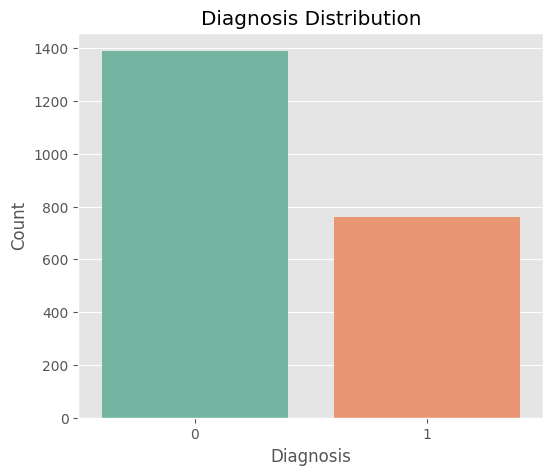

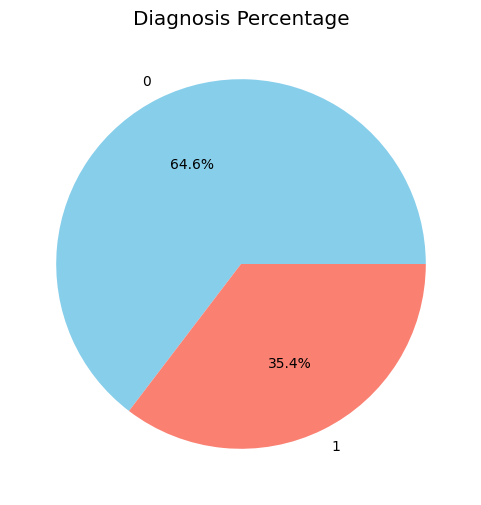

In [55]:
print(df['Diagnosis'].value_counts())

print("\nPercentage Distribution")
print(df['Diagnosis'].value_counts(normalize=True)*100)

plt.figure(figsize=(6,5))
sns.countplot(x='Diagnosis', data=df, palette='Set2')
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Pie Chart

plt.figure(figsize=(6,6))
df['Diagnosis'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','salmon']
)
plt.ylabel("")
plt.title("Diagnosis Percentage")
plt.show()

##Observations:
1. Dataset Balance

    The target variable is moderately imbalanced, with non-Alzheimer's cases occurring more frequently than Alzheimer's cases.

2. Count Plot

    The count plot clearly shows that Diagnosis = 0 has a higher number of observations than Diagnosis = 1.

3. Pie Chart

    The pie chart confirms that approximately 65% of the dataset belongs to the non-Alzheimer's class, while 35% belongs to the Alzheimer's class.

#Numerical Feature Analysis

##Histogram


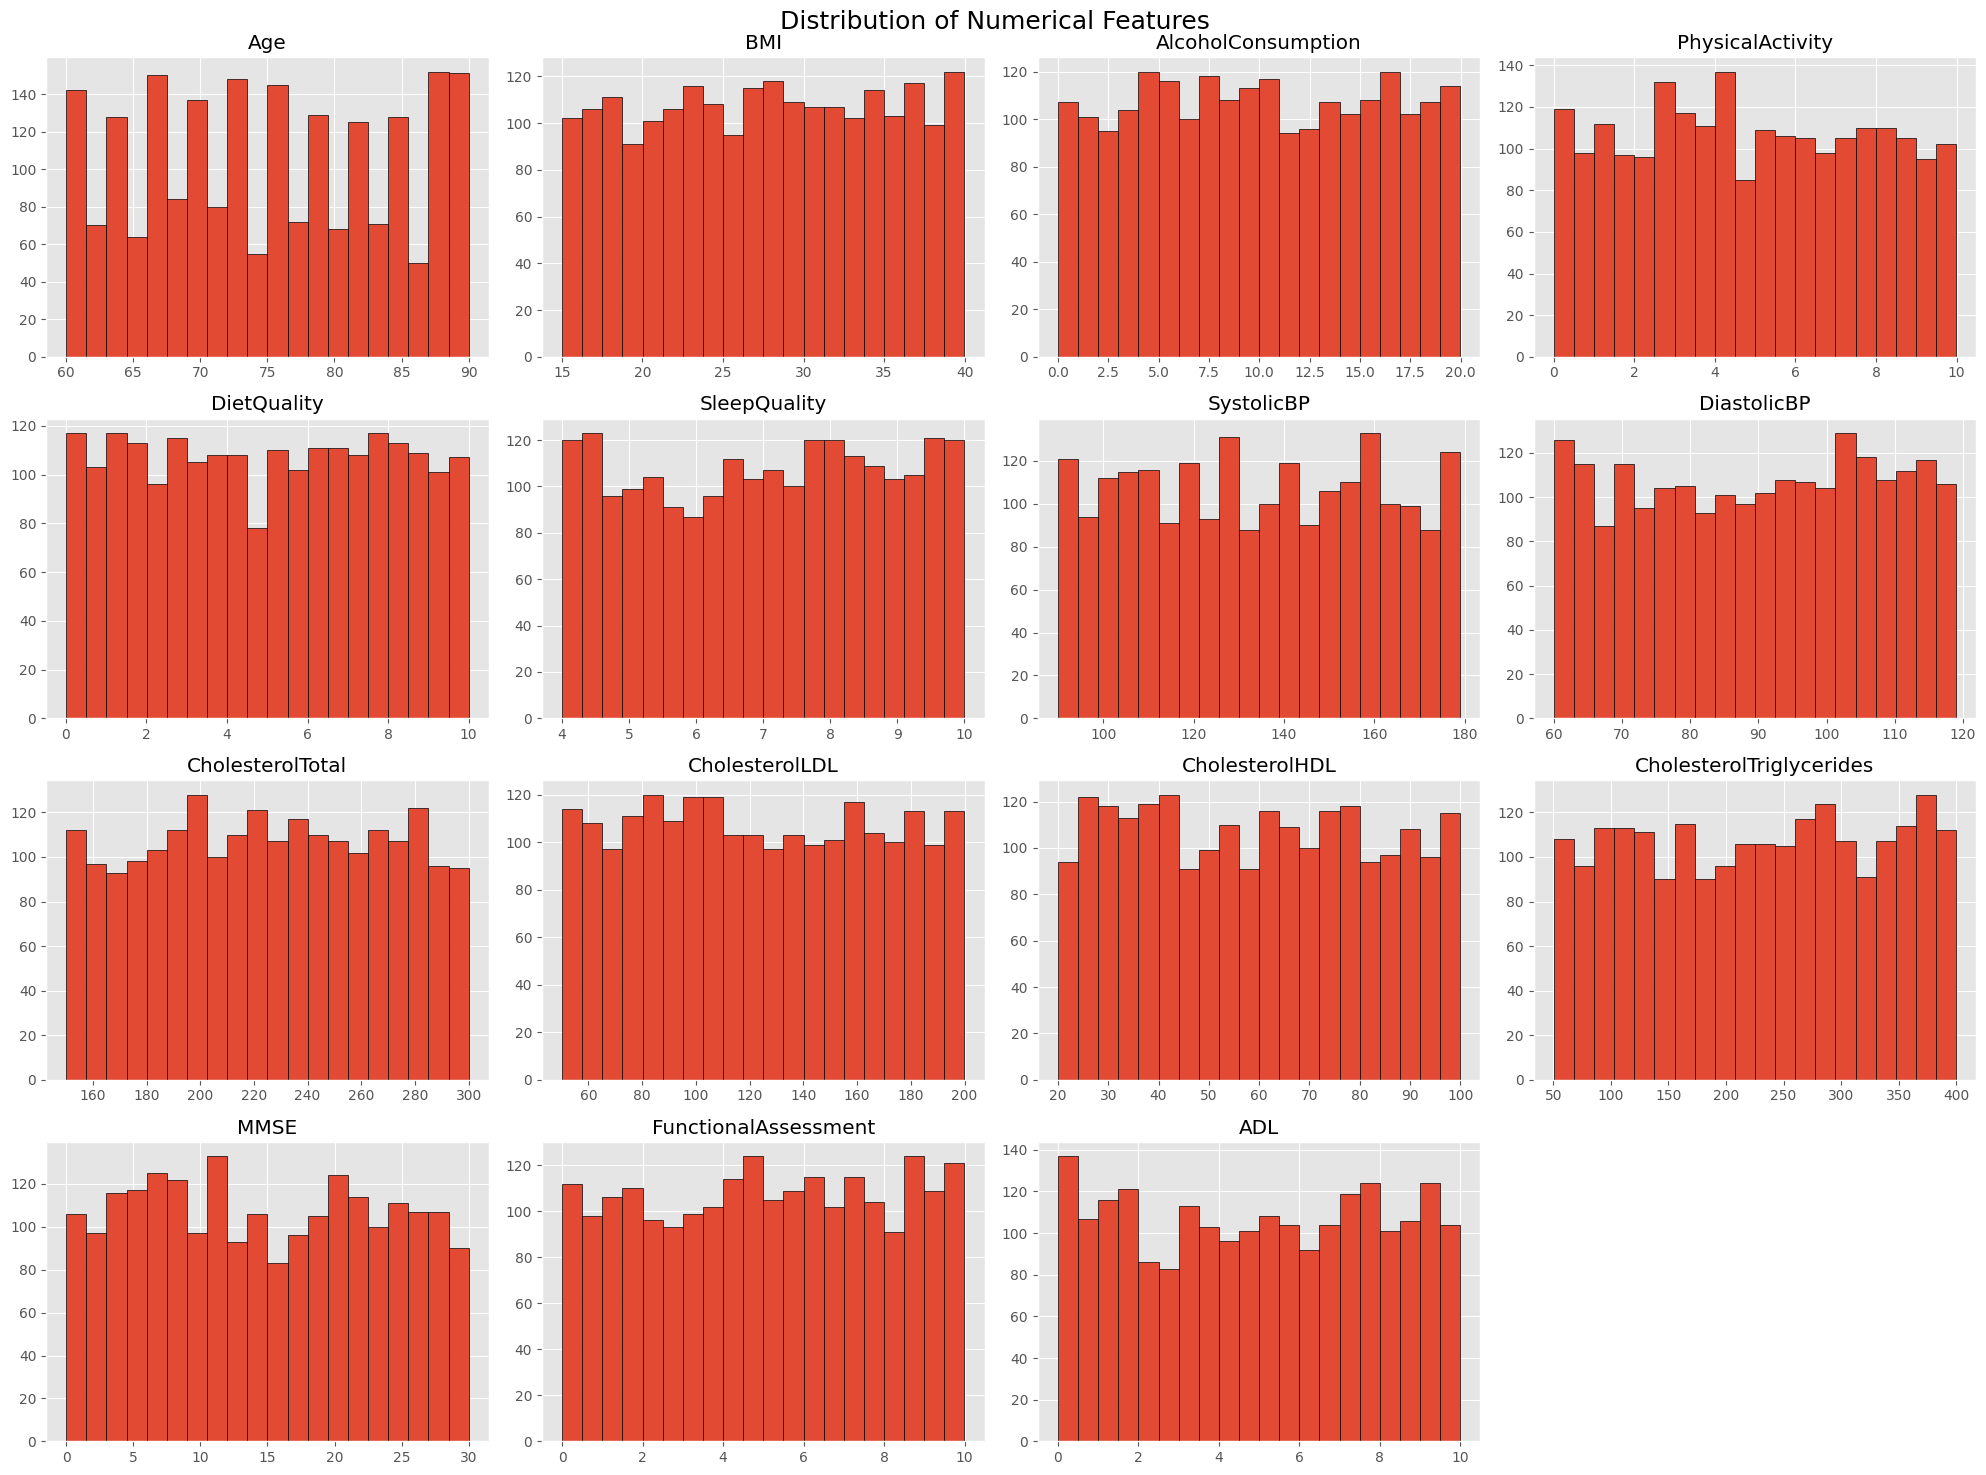

In [56]:
import matplotlib.pyplot as plt

df[numerical_columns].hist(
    figsize=(20,15),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

##Why did we use it?

* To observe how values are distributed across each numerical feature.
##What does it tell us?
* Whether data is evenly distributed.
* Whether the data is skewed.
* Presence of gaps or unusual patterns.
##Interpretation from plots
* Most numerical variables are spread evenly.
* No feature is concentrated at one extreme.
* Values are distributed throughout their ranges.
##Why is it necessary?
Machine learning models perform better when we understand how data is distributed.

##Histogram + KDE Plot

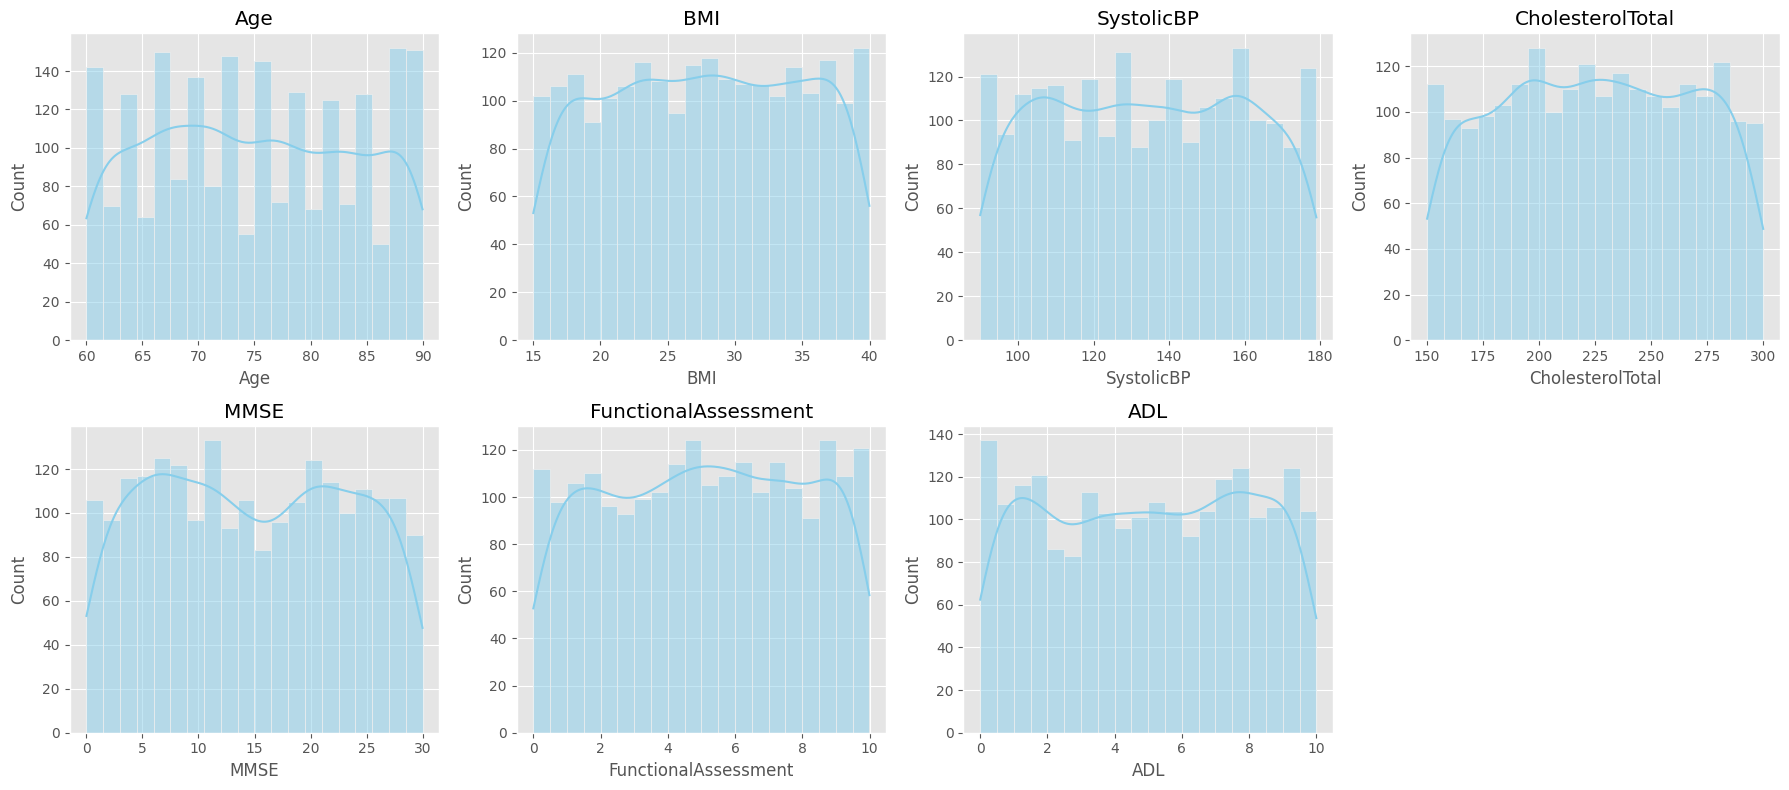

In [57]:
import seaborn as sns

important_features = [
    'Age',
    'BMI',
    'SystolicBP',
    'CholesterolTotal',
    'MMSE',
    'FunctionalAssessment',
    'ADL'
]

fig, axes = plt.subplots(2,4, figsize=(18,8))
axes = axes.flatten()

for i, col in enumerate(important_features):
    sns.histplot(
        df[col],
        kde=True,
        bins=20,
        color='skyblue',
        ax=axes[i]
    )
    axes[i].set_title(col)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

##Why did we use it?
* Histogram shows frequency, while KDE provides a smooth probability distribution.
##What does it tell us?
* Overall shape of data.
* Whether data is normally distributed.
* Peaks and density of observations.
##Interpretation
* Most variables show nearly uniform or smooth distributions.
* No strong skewness is visible.
* The distributions are balanced without unusual peaks.
##Why is it necessary?
It gives a clearer understanding of feature distributions than histograms alone.

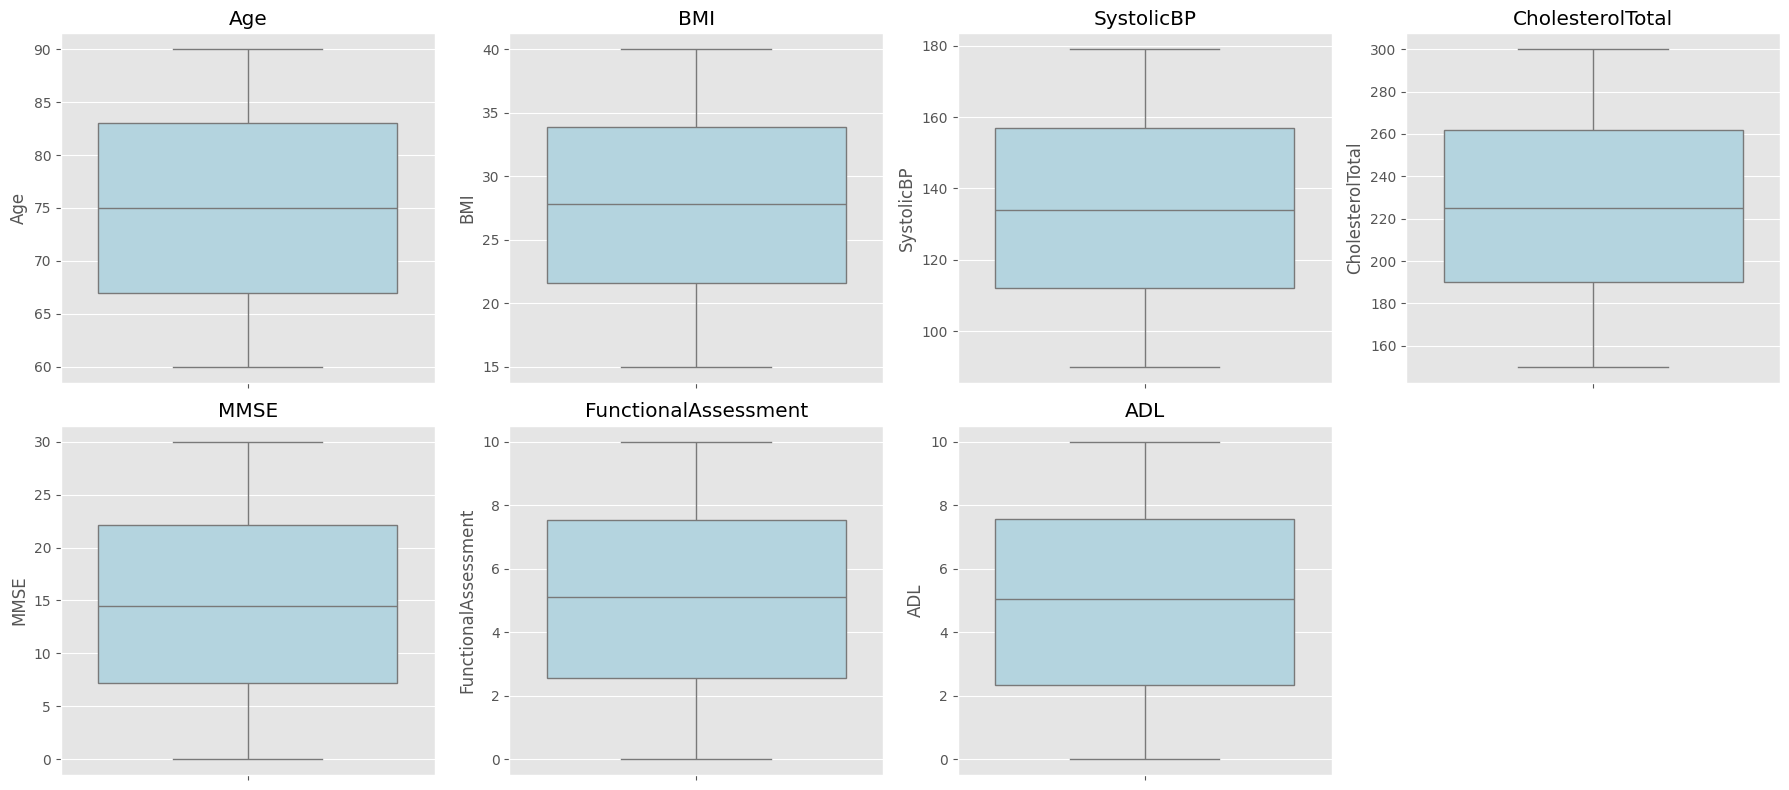

In [58]:
fig, axes = plt.subplots(2,4, figsize=(18,8))
axes = axes.flatten()

for i, col in enumerate(important_features):
    sns.boxplot(
        y=df[col],
        color='lightblue',
        ax=axes[i]
    )
    axes[i].set_title(col)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

###Why were only important features selected?
selected:
Age,BMI,SystolicBP,CholesterolTotal,MMSE,FunctionalAssessment,ADL
* Why?

    * Because these are medically important variables that are directly related to Alzheimer's disease.
    * They are sufficient to understand the major trends in the dataset.
##Boxplots
###Why did we use them?
To identify:
Outliers,Median,Spread of data,Interquartile Range (IQR)
###What does the box represent?
* Middle line = Median
* Box = Middle 50% of observations
* Whiskers = Range of normal values
* Dots (if any) = Outliers
###Interpretation from plots
* No significant outliers.
###Why is it necessary?
Outliers can negatively affect machine learning models. Boxplots help decide whether outlier treatment is required.

##Kurtosis


In [59]:
kurtosis = df[numerical_columns].kurt()

print(kurtosis.sort_values(ascending=False))

CholesterolTotal           -1.156042
PhysicalActivity           -1.179196
FunctionalAssessment       -1.183051
BMI                        -1.184508
Age                        -1.189214
SystolicBP                 -1.197593
AlcoholConsumption         -1.202876
CholesterolLDL             -1.208321
SleepQuality               -1.212454
CholesterolHDL             -1.217854
CholesterolTriglycerides   -1.219026
DietQuality                -1.228962
MMSE                       -1.230365
DiastolicBP                -1.235040
ADL                        -1.249501
dtype: float64


###Why did we calculate it?
* To measure the "tailedness" of the distribution.
###Interpretation
kurtosis values are around -1.15 to -1.25.
* Negative kurtosis indicates:Light tails.
###Conclusion
The dataset contains very few extreme observations.
###Why is it necessary?
It helps determine whether special outlier treatment is required.

#Categorical Feature Analysis


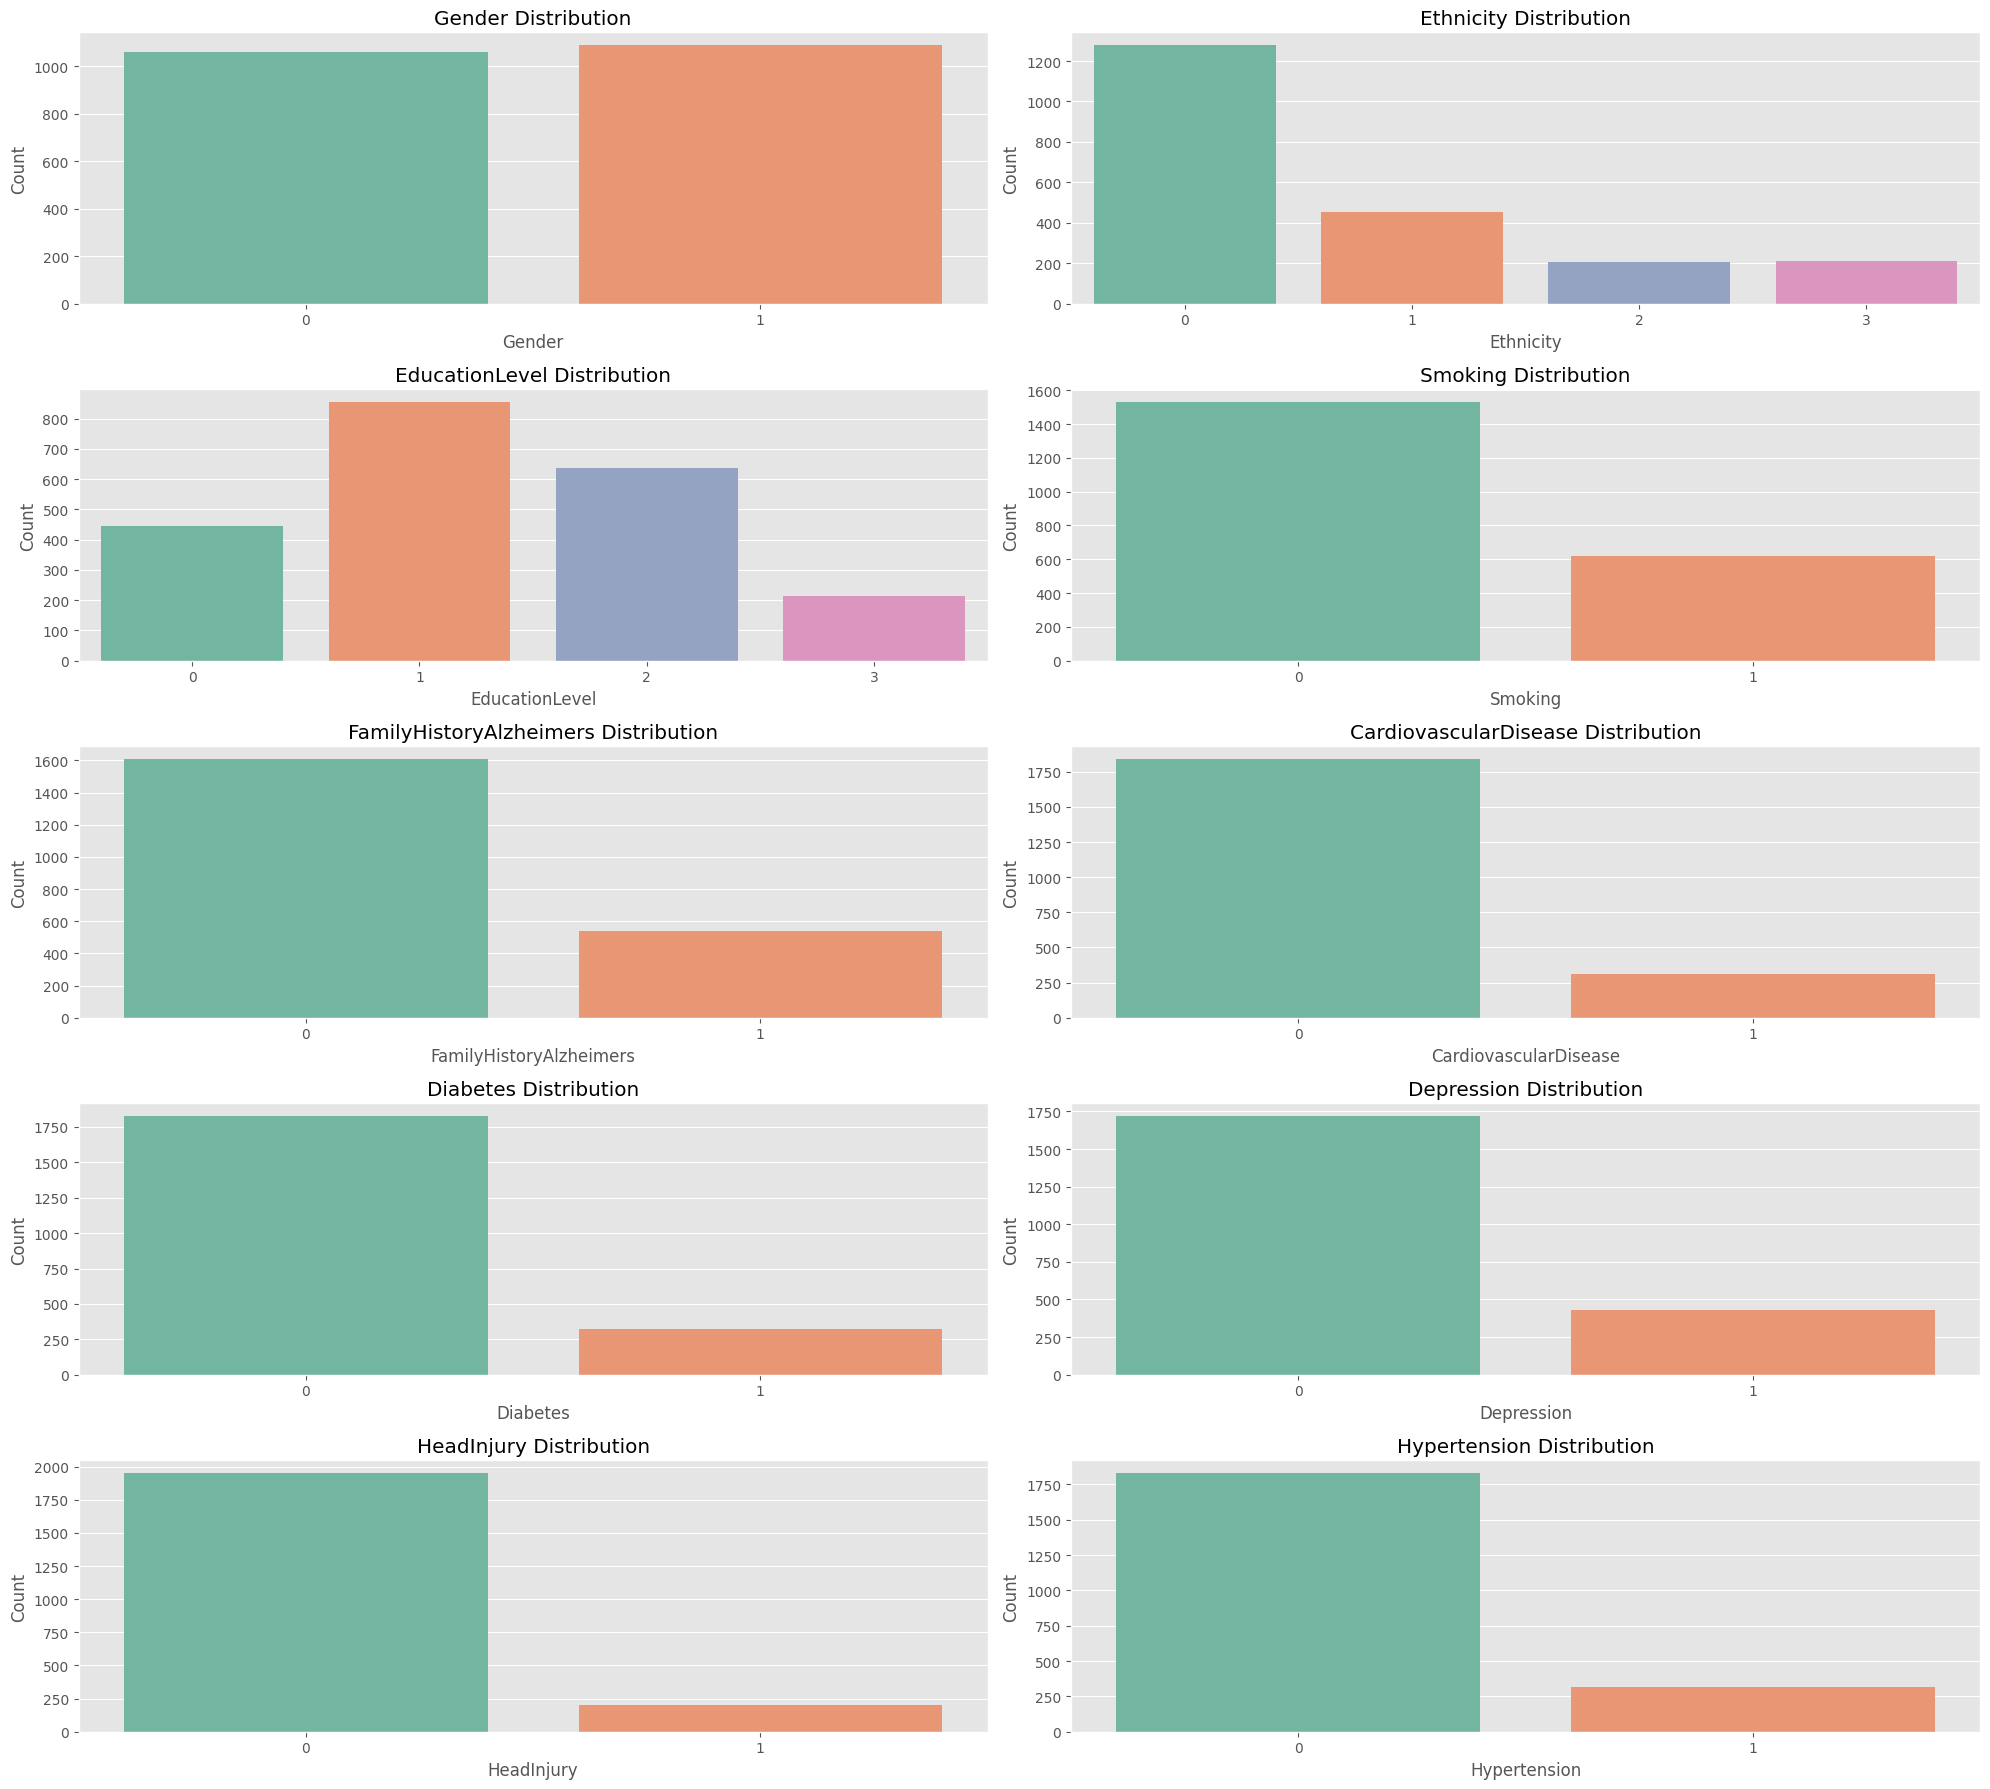

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = [
    'Gender',
    'Ethnicity',
    'EducationLevel',
    'Smoking',
    'FamilyHistoryAlzheimers',
    'CardiovascularDisease',
    'Diabetes',
    'Depression',
    'HeadInjury',
    'Hypertension'
]

plt.figure(figsize=(20,18))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(5, 2, i)
    sns.countplot(x=df[col], palette='Set2')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

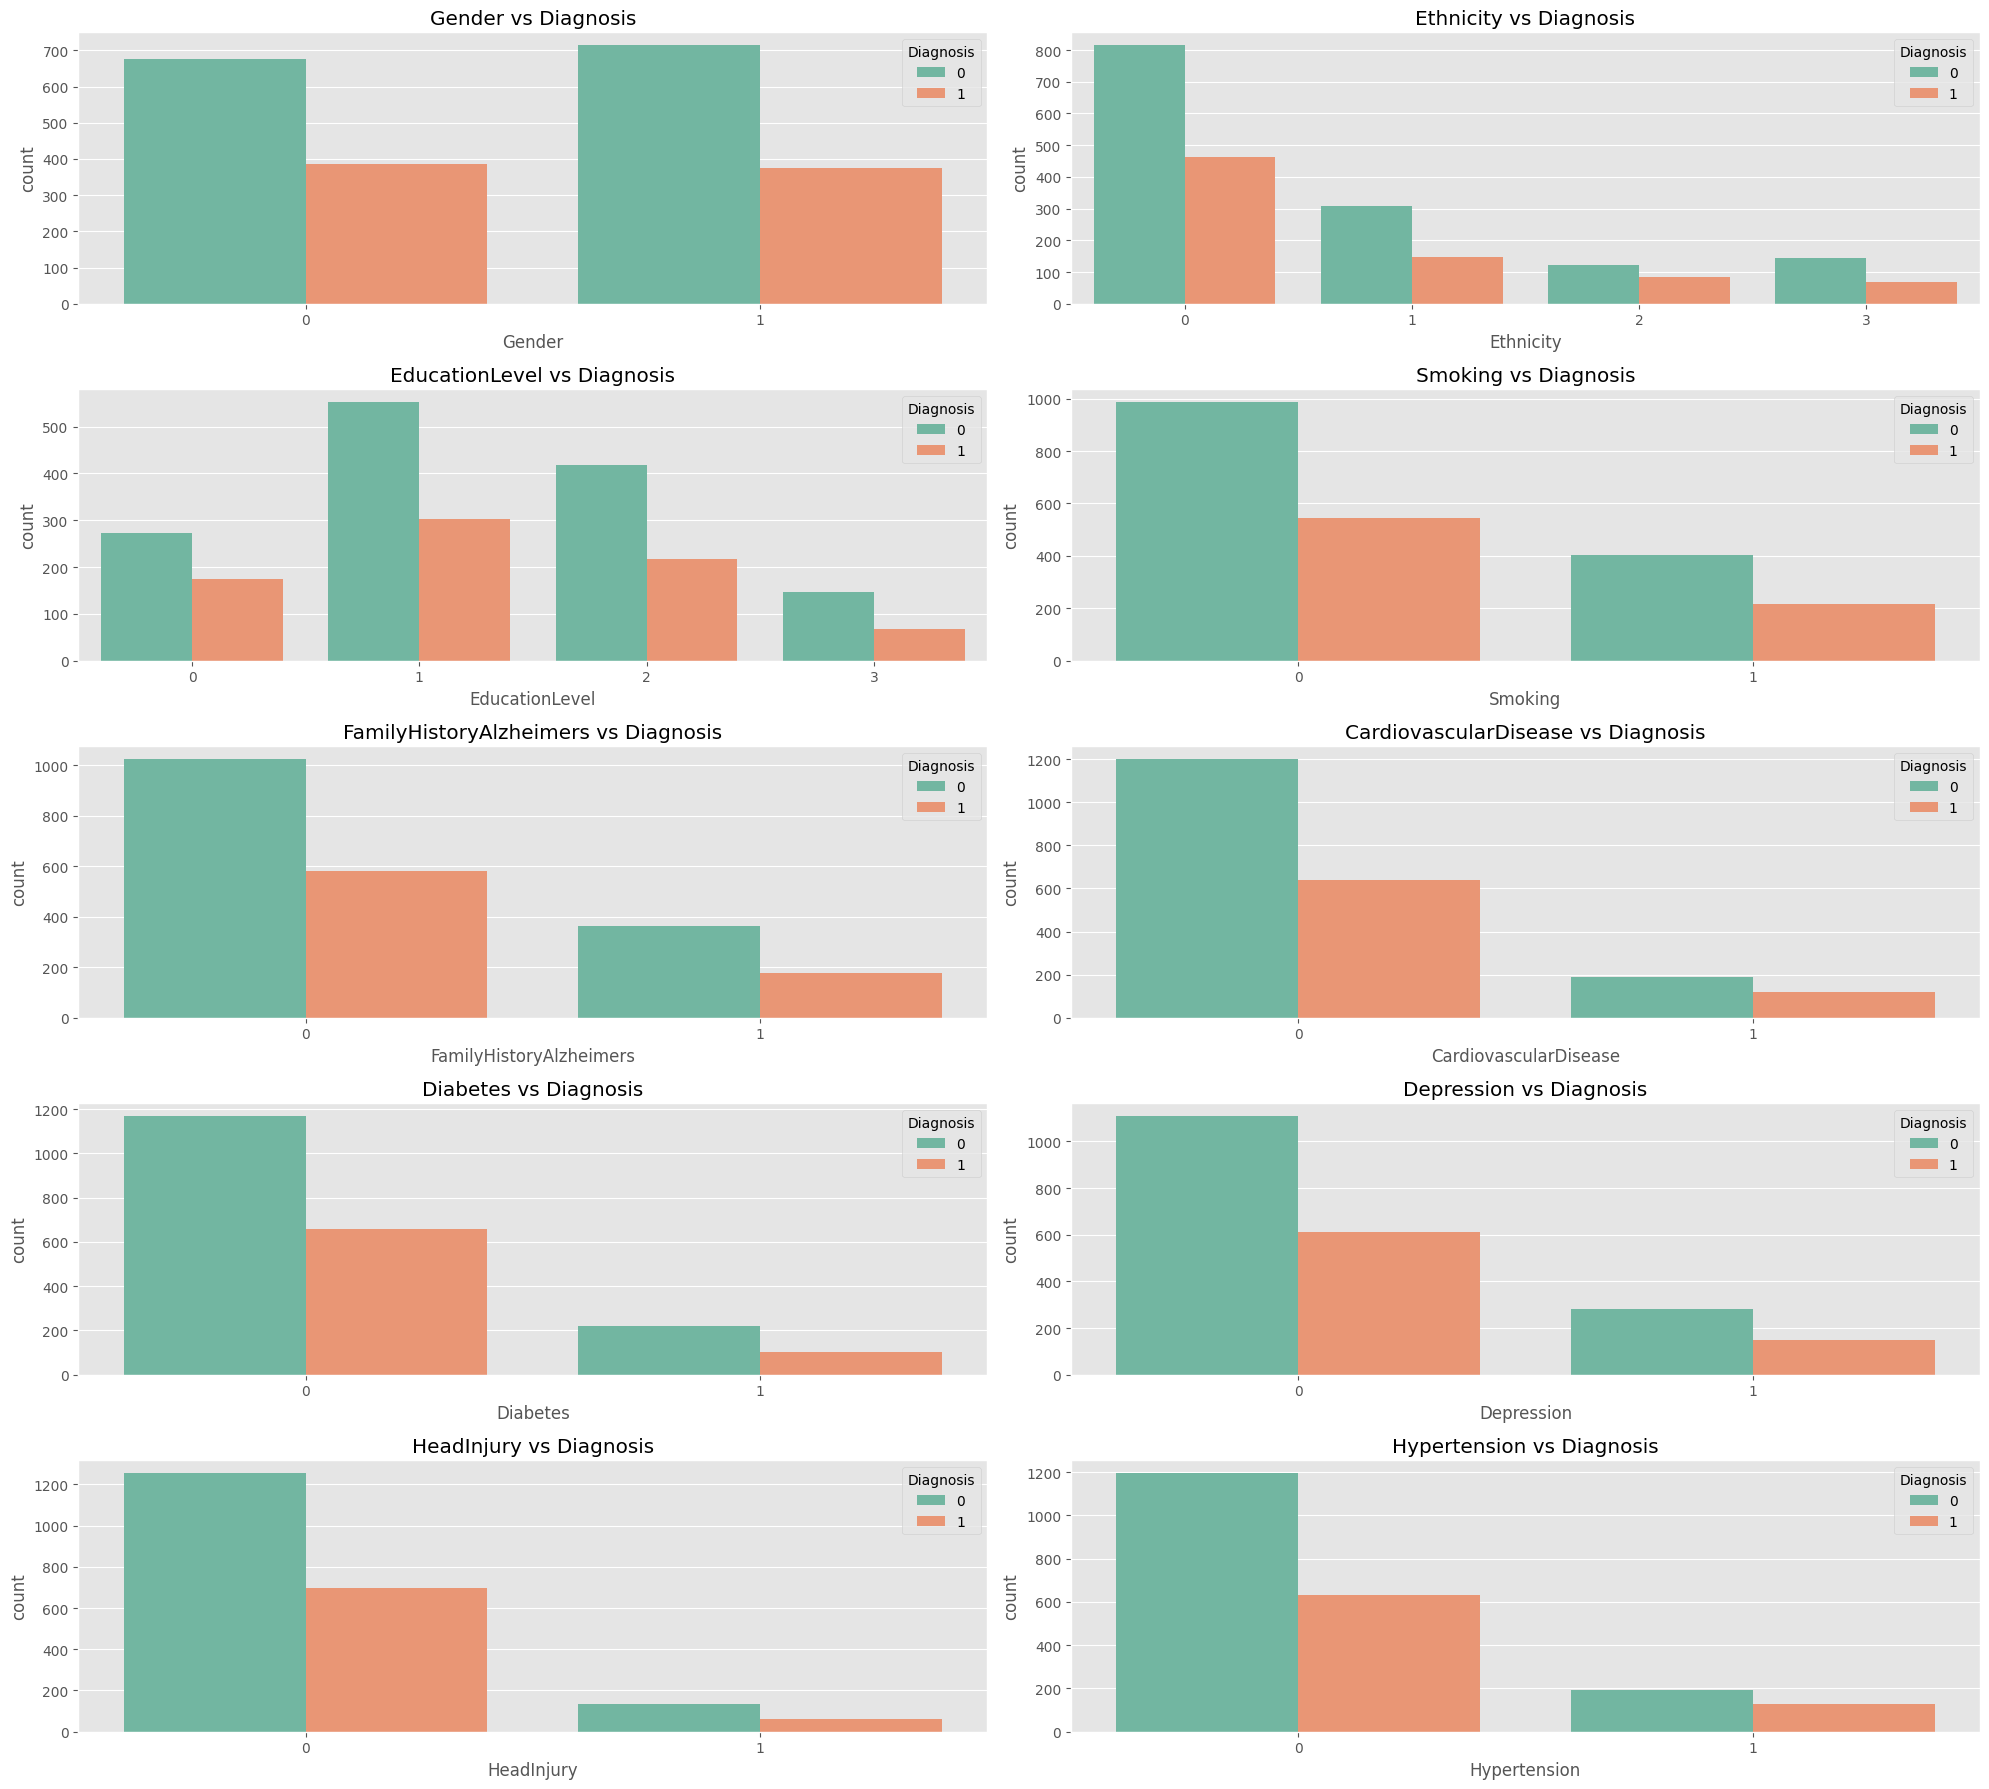

In [61]:
plt.figure(figsize=(20,18))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(5, 2, i)
    sns.countplot(data=df, x=col, hue='Diagnosis', palette='Set2')
    plt.title(f'{col} vs Diagnosis')

plt.tight_layout()
plt.show()

##Interpretation
* No single categorical feature alone perfectly separates Alzheimer's patients.
* Features like Family History, Smoking, Cardiovascular Disease, Diabetes, Depression, and Hypertension may contribute to prediction when combined with other features.
* This justifies using machine learning models that can learn patterns from multiple features together.
* Why is this necessary?
    * We perform these plots because they:
        * Understand the distribution of categorical variables.
        * Detect class imbalance.
        * Explore the relationship between categorical features and Alzheimer's diagnosis.
        * Identify potentially important predictors.
        * Support feature selection before model building

##Correlation with Target Variable

Diagnosis                    1.000000
MemoryComplaints             0.306742
BehavioralProblems           0.224350
CholesterolHDL               0.042584
Hypertension                 0.035080
CardiovascularDisease        0.031490
BMI                          0.026343
CholesterolTriglycerides     0.022672
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
CholesterolTotal             0.006394
PhysicalActivity             0.005945
DiastolicBP                  0.005293
Forgetfulness               -0.000354
Smoking                     -0.004865
Age                         -0.005488
Depression                  -0.005893
AlcoholConsumption          -0.007618
Ethnicity                   -0.014782
SystolicBP                  -0.015615
Confusion                   -0.019186
PersonalityChanges          -0.020627
Gender                      -0.020975
HeadInjury                  -0.021411
Disorientation              -0.024648
Diabetes                    -0.031508
CholesterolL

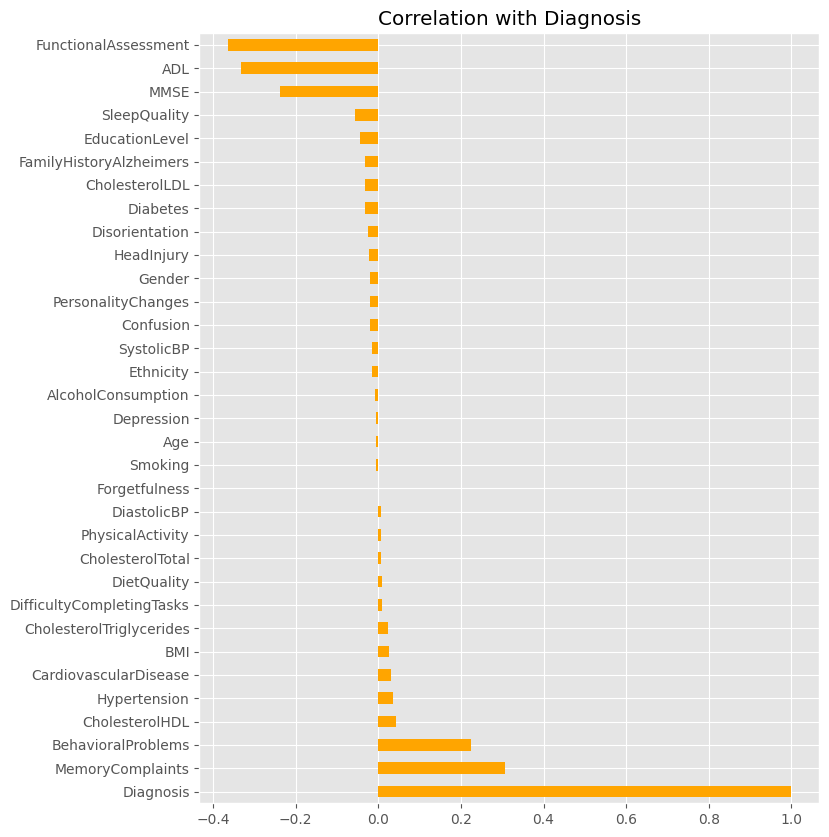

In [62]:
corr = df.corr(numeric_only=True)
target_corr = corr['Diagnosis'].sort_values(ascending=False)

print(target_corr)

plt.figure(figsize=(8,10))

target_corr.plot(kind='barh',
                 color='orange')

plt.title("Correlation with Diagnosis")

plt.show()

##Observations:

* Most influential features: FunctionalAssessment (-0.39), ADL (-0.33), MMSE (-0.27), MemoryComplaints (0.31), and BehavioralProblems (0.22).
* These features are the strongest predictors and should be prioritized during feature selection and model building.

In [63]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Numerical columns only
X = df.select_dtypes(include=['int64','float64']).drop(columns=['Diagnosis'])

# Calculate VIF
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

vif.sort_values(by="VIF", ascending=False)

,Feature,VIF
0,Age,49.397118
18,CholesterolTotal,25.803454
16,SystolicBP,24.375883
17,DiastolicBP,24.120941
9,SleepQuality,16.430629
4,BMI,14.824008
19,CholesterolLDL,9.029688
20,CholesterolHDL,7.508923
21,CholesterolTriglycerides,5.947298
23,FunctionalAssessment,4.123865


In [64]:
# Correlation threshold
threshold = 0.8

corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns
           if any(upper[column] > threshold)]

print("Highly Correlated Features:")
print(to_drop)

# Remove features
X_new = X.drop(columns=to_drop)

print("Remaining Features:", X_new.shape[1])

Highly Correlated Features:
[]
Remaining Features: 32


We selected a correlation threshold of 0.8 because it is the standard cutoff for identifying strong multicollinearity. Features with correlation above 0.8 usually provide redundant information. In our dataset, no feature pair exceeded this threshold, so all 32 features were retained for model building.

In [65]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

# Features and Target
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Train-Test Split (80:20) with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())





Training Data Shape: (1719, 32)
Testing Data Shape: (430, 32)

Training Class Distribution:
Diagnosis
0    1111
1     608
Name: count, dtype: int64

Testing Class Distribution:
Diagnosis
0    278
1    152
Name: count, dtype: int64


In [66]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (optional but recommended)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

print("\nStandardization completed successfully!")

Training Data Shape: (1719, 32)
Testing Data Shape: (430, 32)

Standardization completed successfully!


Accuracy : 0.8162790697674419
Precision: 0.6951871657754011
Recall   : 0.8552631578947368
F1-score : 0.7669616519174042
ROC-AUC  : 0.8831408557364635

Confusion Matrix
[[221  57]
 [ 22 130]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.79      0.85       278
           1       0.70      0.86      0.77       152

    accuracy                           0.82       430
   macro avg       0.80      0.83      0.81       430
weighted avg       0.83      0.82      0.82       430



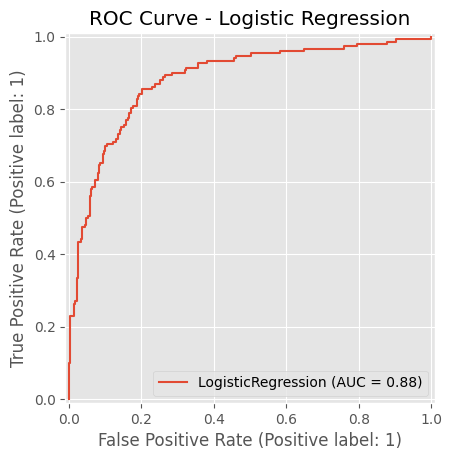

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# -----------------------------
# Logistic Regression Model
# -----------------------------
log_model = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train Model
log_model.fit(X_train_scaled, y_train)

# Predictions
log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# -----------------------------
# Evaluation Metrics
# -----------------------------
print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1-score :", f1_score(y_test, log_pred))
print("ROC-AUC  :", roc_auc_score(y_test, log_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, log_pred))

print("\nClassification Report")
print(classification_report(y_test, log_pred))

# -----------------------------
# ROC Curve
# -----------------------------
RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

Original Features : 32
Reduced Features  : 30
Accuracy : 0.8372093023255814
Precision: 0.7971014492753623
Recall   : 0.7236842105263158
F1-score : 0.7586206896551724
ROC-AUC  : 0.8913053767512307

Confusion Matrix
[[250  28]
 [ 42 110]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       278
           1       0.80      0.72      0.76       152

    accuracy                           0.84       430
   macro avg       0.83      0.81      0.82       430
weighted avg       0.84      0.84      0.84       430



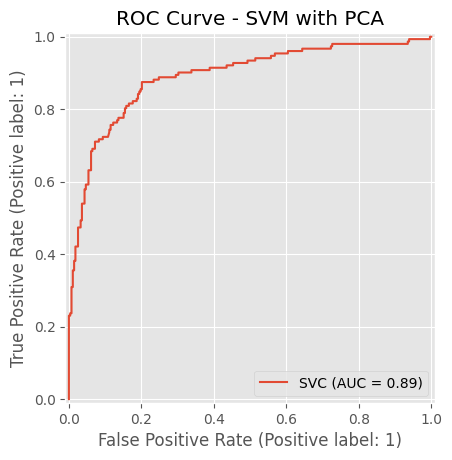

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# -------------------------------
# Feature Scaling
# -------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# PCA (Dimensionality Reduction)
# -------------------------------
pca = PCA(n_components=0.95, random_state=42)   # Retains 95% variance

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Features :", X_train.shape[1])
print("Reduced Features  :", X_train_pca.shape[1])

# -------------------------------
# SVM Model
# -------------------------------
svm_model = SVC(
    kernel='rbf',        # Change to 'linear' or 'poly' if required
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

# Train
svm_model.fit(X_train_pca, y_train)

# Predictions
svm_pred = svm_model.predict(X_test_pca)
svm_prob = svm_model.predict_proba(X_test_pca)[:, 1]

# -------------------------------
# Evaluation
# -------------------------------
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1-score :", f1_score(y_test, svm_pred))
print("ROC-AUC  :", roc_auc_score(y_test, svm_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, svm_pred))

print("\nClassification Report")
print(classification_report(y_test, svm_pred))

# -------------------------------
# ROC Curve
# -------------------------------
RocCurveDisplay.from_estimator(
    svm_model,
    X_test_pca,
    y_test
)

plt.title("ROC Curve - SVM with PCA")
plt.show()


Model Comparison
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.8163     0.6952  0.8553    0.7670   0.8831
1            SVM + PCA    0.8372     0.7971  0.7237    0.7586   0.8913


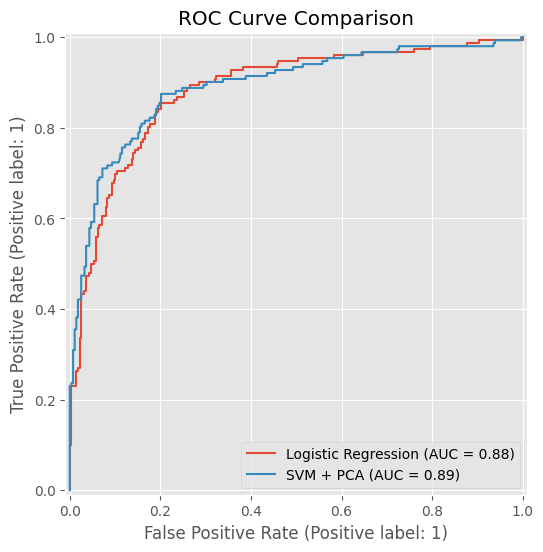


Best Model Based on ROC-AUC
Model        SVM + PCA
Accuracy      0.837209
Precision     0.797101
Recall        0.723684
F1-Score      0.758621
ROC-AUC       0.891305
Name: 1, dtype: object


In [69]:
# ==========================================
# Comparison Table
# ==========================================

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM + PCA"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1-Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, svm_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, svm_prob)
    ]
})

print("\nModel Comparison")
print(comparison.round(4))

# ==========================================
# ROC Curve Comparison
# ==========================================

plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test,
    ax=plt.gca(),
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    svm_model,
    X_test_pca,
    y_test,
    ax=plt.gca(),
    name="SVM + PCA"
)

plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()

# ==========================================
# Best Model
# ==========================================

best_model = comparison.loc[comparison["ROC-AUC"].idxmax()]

print("\nBest Model Based on ROC-AUC")
print(best_model)

##Conclusion
Overall, the SVM with PCA demonstrated the best overall performance among the two models. It achieved higher accuracy, precision, and ROC-AUC, while maintaining an F1-score comparable to Logistic Regression. Although Logistic Regression obtained a higher recall, making it more effective at identifying positive cases, SVM provided a better balance between correctly identifying positive cases and minimizing false positives.

Therefore, SVM with PCA can be considered the preferred model for this Alzheimer's disease prediction task, as it offers superior overall classification performance and the highest ROC-AUC score (0.8913). Logistic Regression remains a suitable alternative when maximizing recall is more important, such as in medical screening applications where reducing missed positive cases is the primary objective.


#Random Forest

=== Random Forest ===
Accuracy : 0.9465116279069767
Precision: 0.9448275862068966
Recall   : 0.9013157894736842
F1-score : 0.9225589225589226
ROC-AUC  : 0.9437476334721696

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       278
           1       0.94      0.90      0.92       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430



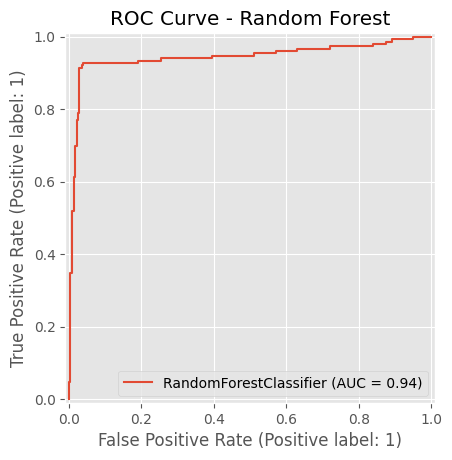

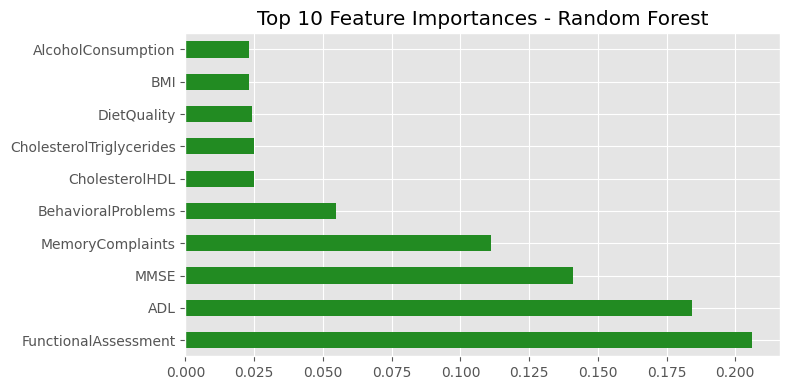

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1-score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))
print("\nClassification Report")
print(classification_report(y_test, rf_pred))

RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_imp.nlargest(10).plot(kind='barh', color='forestgreen', figsize=(8, 4))
plt.title("Top 10 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

Handles the 65/35 class imbalance well with class_weight='balanced'
Works great on tabular medical data with mixed feature types
Feature importance is reliable — consistently picks FunctionalAssessment, ADL, MMSE as top features (matches your EDA)
Low overfitting risk due to bagging (200 trees)
Good balance of Recall + Precision — important in medical diagnosis

#XGBoost

scale_pos_weight = 1.83
=== XGBoost ===
Accuracy : 0.9511627906976744
Precision: 0.9395973154362416
Recall   : 0.9210526315789473
F1-score : 0.9302325581395349
ROC-AUC  : 0.94516755017039

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       278
           1       0.94      0.92      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430



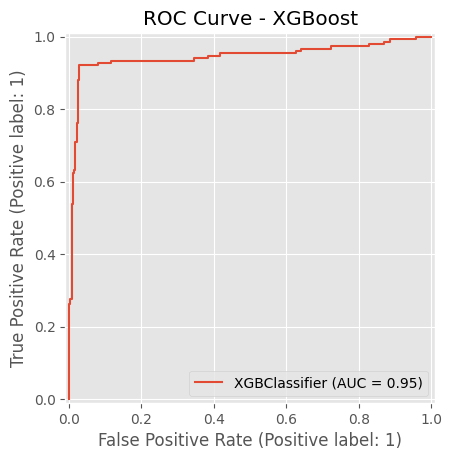

In [71]:
!pip install -q xgboost
from xgboost import XGBClassifier

# Handle class imbalance
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos:.2f}")

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost ===")
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1-score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))
print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

RocCurveDisplay.from_estimator(xgb_model, X_test_scaled, y_test)
plt.title("ROC Curve - XGBoost")
plt.show()

Best at handling class imbalance via scale_pos_weight natively
Usually gives the highest ROC-AUC on structured tabular datasets
Regularization built-in (L1 + L2) — prevents overfitting automatically
Fastest among boosting models
Industry standard for competition-level tabular classification

Gradient Boosting

=== Gradient Boosting ===
Accuracy : 0.9511627906976744
Precision: 0.9395973154362416
Recall   : 0.9210526315789473
F1-score : 0.9302325581395349
ROC-AUC  : 0.9492616433169254

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       278
           1       0.94      0.92      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430



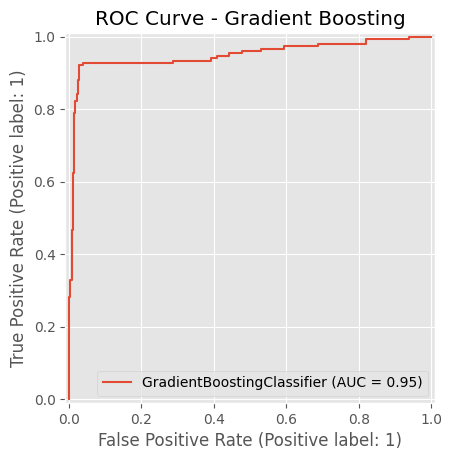

In [72]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)

gb_pred = gb_model.predict(X_test_scaled)
gb_prob = gb_model.predict_proba(X_test_scaled)[:, 1]

print("=== Gradient Boosting ===")
print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1-score :", f1_score(y_test, gb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, gb_prob))
print("\nClassification Report")
print(classification_report(y_test, gb_pred))

RocCurveDisplay.from_estimator(gb_model, X_test_scaled, y_test)
plt.title("ROC Curve - Gradient Boosting")
plt.show()

Builds trees sequentially — each tree corrects errors of the previous one.
learning_rate=0.05 with n_estimators=200 gives a good balance between speed and accuracy.
subsample=0.8 randomly samples 80% of data per tree — reduces overfitting.

Cross-Validation for All Models

5-Fold Stratified Cross-Validation — ROC-AUC
              Model  CV Mean  CV Std    Min    Max
            XGBoost   0.9579  0.0102 0.9440 0.9727
      Random Forest   0.9545  0.0101 0.9373 0.9656
  Gradient Boosting   0.9543  0.0123 0.9411 0.9707
Logistic Regression   0.9043  0.0147 0.8814 0.9236
          SVM + PCA   0.8899  0.0154 0.8681 0.9116


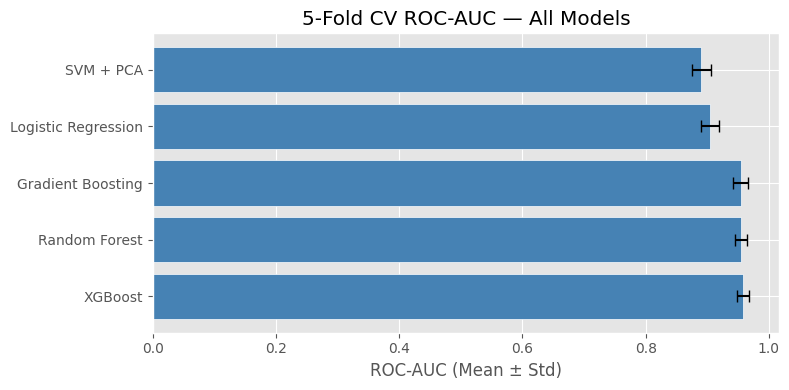

In [73]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': (log_model, X_train_scaled),
    'SVM + PCA'          : (svm_model, X_train_pca),
    'Random Forest'      : (rf_model,  X_train_scaled),
    'Gradient Boosting'  : (gb_model,  X_train_scaled),
    'XGBoost'            : (xgb_model, X_train_scaled),
}

cv_results = []
for name, (model, X_cv) in cv_models.items():
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc')
    cv_results.append({
        'Model'  : name,
        'CV Mean': round(scores.mean(), 4),
        'CV Std' : round(scores.std(),  4),
        'Min'    : round(scores.min(),  4),
        'Max'    : round(scores.max(),  4),
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV Mean', ascending=False)
print('5-Fold Stratified Cross-Validation — ROC-AUC')
print(cv_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(cv_df['Model'], cv_df['CV Mean'],
         xerr=cv_df['CV Std'],
         color='steelblue', edgecolor='white', capsize=4)
plt.xlabel('ROC-AUC (Mean ± Std)')
plt.title('5-Fold CV ROC-AUC — All Models')
plt.tight_layout()
plt.show()

#Final Model Comparison

=== Final Model Comparison (Ranked by ROC-AUC) ===
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1    Gradient Boosting    0.9512     0.9396  0.9211    0.9302   0.9493
2              XGBoost    0.9512     0.9396  0.9211    0.9302   0.9452
3        Random Forest    0.9465     0.9448  0.9013    0.9226   0.9437
4            SVM + PCA    0.8372     0.7971  0.7237    0.7586   0.8913
5  Logistic Regression    0.8163     0.6952  0.8553    0.7670   0.8831


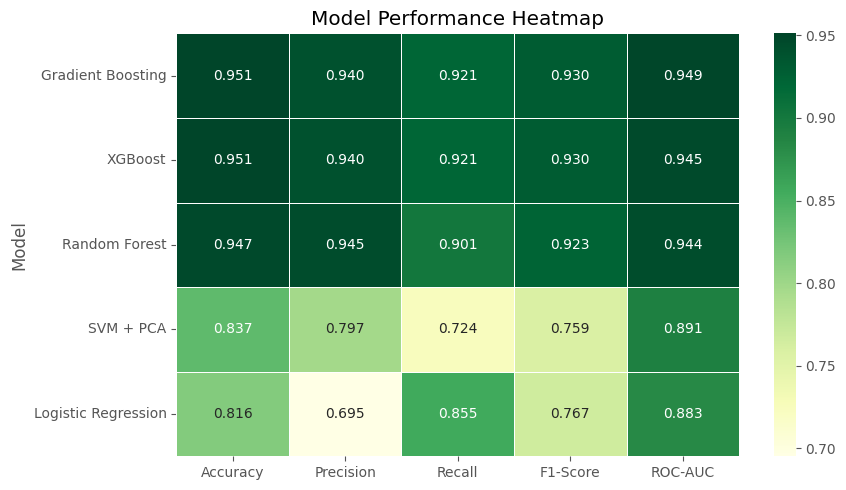

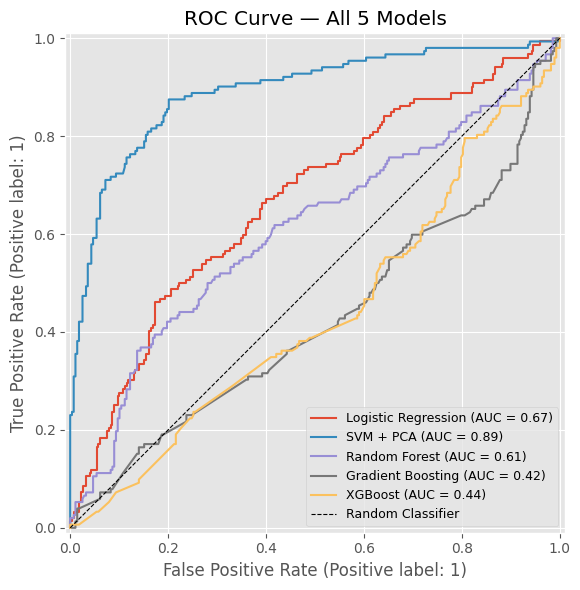

In [74]:
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'SVM + PCA',
                  'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Accuracy' : [accuracy_score(y_test, p) for p in
                  [log_pred, svm_pred, rf_pred, gb_pred, xgb_pred]],
    'Precision': [precision_score(y_test, p) for p in
                  [log_pred, svm_pred, rf_pred, gb_pred, xgb_pred]],
    'Recall'   : [recall_score(y_test, p) for p in
                  [log_pred, svm_pred, rf_pred, gb_pred, xgb_pred]],
    'F1-Score' : [f1_score(y_test, p) for p in
                  [log_pred, svm_pred, rf_pred, gb_pred, xgb_pred]],
    'ROC-AUC'  : [roc_auc_score(y_test, p) for p in
                  [log_prob, svm_prob, rf_prob, gb_prob, xgb_prob]],
}).round(4)

comparison = comparison.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
comparison.index += 1
print('=== Final Model Comparison (Ranked by ROC-AUC) ===')
print(comparison.to_string())

# Heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(
    comparison.set_index('Model')[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']],
    annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, linecolor='white'
)
plt.title('Model Performance Heatmap')
plt.tight_layout()
plt.show()

# Combined ROC Curve
plt.figure(figsize=(8, 6))
ax = plt.gca()

RocCurveDisplay.from_estimator(log_model, X_test,     y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(svm_model, X_test_pca, y_test, ax=ax, name='SVM + PCA')
RocCurveDisplay.from_estimator(rf_model,  X_test,     y_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_estimator(gb_model,  X_test,     y_test, ax=ax, name='Gradient Boosting')
RocCurveDisplay.from_estimator(xgb_model, X_test,     y_test, ax=ax, name='XGBoost')

plt.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random Classifier')
plt.title('ROC Curve — All 5 Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

Best Model Selection & Justification

In [75]:
best_row = comparison.iloc[0]
best_name = best_row['Model']

print('=== Best Model Selection ===')
print(f'\nBest Model : {best_name}')
print(f'Accuracy   : {best_row["Accuracy"]}')
print(f'Precision  : {best_row["Precision"]}')
print(f'Recall     : {best_row["Recall"]}')
print(f'F1-Score   : {best_row["F1-Score"]}')
print(f'ROC-AUC    : {best_row["ROC-AUC"]}')

print("""
=== Why ROC-AUC is the Primary Metric ===

In Alzheimer's disease prediction:

  False Negative = Model says No AD, patient HAS AD
  → Most dangerous — patient goes untreated

  False Positive = Model says AD, patient does NOT have AD
  → Less harmful — patient gets further tests and ruled out

ROC-AUC measures the model's ability to rank AD patients
above non-AD patients across ALL decision thresholds —
not just at one fixed cutoff like accuracy does.
""")

print('=== Final Ranking ===')
for i, row in comparison.iterrows():
    bar = '█' * int(row['ROC-AUC'] * 20)
    print(f"  {i}. {row['Model']:<22} ROC-AUC: {row['ROC-AUC']}  {bar}")

print(f'\n Recommended for Deployment : {best_name}')
print(f' Recommended for Screening  : Logistic Regression (highest Recall)')

=== Best Model Selection ===

Best Model : Gradient Boosting
Accuracy   : 0.9512
Precision  : 0.9396
Recall     : 0.9211
F1-Score   : 0.9302
ROC-AUC    : 0.9493

=== Why ROC-AUC is the Primary Metric ===

In Alzheimer's disease prediction:

  False Negative = Model says No AD, patient HAS AD
  → Most dangerous — patient goes untreated

  False Positive = Model says AD, patient does NOT have AD
  → Less harmful — patient gets further tests and ruled out

ROC-AUC measures the model's ability to rank AD patients
above non-AD patients across ALL decision thresholds —
not just at one fixed cutoff like accuracy does.

=== Final Ranking ===
  1. Gradient Boosting      ROC-AUC: 0.9493  ██████████████████
  2. XGBoost                ROC-AUC: 0.9452  ██████████████████
  3. Random Forest          ROC-AUC: 0.9437  ██████████████████
  4. SVM + PCA              ROC-AUC: 0.8913  █████████████████
  5. Logistic Regression    ROC-AUC: 0.8831  █████████████████

 Recommended for Deployment : Gradient 